# Taylor Swift: Music Discovery & Lyric Analysis

**Audio-feature exploration, song recommendations, phrase search, and keyword extraction**

**Team:** Supriyaa Chordia and Siya Jatia  
**Context:** UC San Diego DSC 10 course project, 2024

This project explores a historical snapshot of Taylor Swift's discography through Spotify-derived audio features and song lyrics. It combines exploratory visualizations with a content-based song recommender, a case-insensitive lyric search tool, and TF-IDF keyword analysis.

The recommendation approach compares songs by Euclidean distance across selected audio features. Lyric search returns matching lines with surrounding context, while TF-IDF highlights words that distinguish songs on *Lover*.

## Explore the notebook

1. [Data preparation](#data-preparation)
2. [Audio features and catalog patterns](#audio-features)
3. [Content-based song recommendations](#recommendations)
4. [Lyric search](#lyric-search)
5. [Keyword analysis](#keywords)
6. [Limitations and next steps](#limitations)

**Reading and running:** Saved code outputs are preserved from the completed notebook; this edited copy has not been rerun. Popularity measures describe the dataset snapshot, rather than current Spotify rankings. Interactive widgets require a running Jupyter environment and the original data/assets.

**Attribution:** This is a team course project. The assignment scaffold, supplied interface/display helpers, and referenced examples originated in the coursework; this portfolio edit does not claim that all scaffolding was independently developed.


In [436]:
import babypandas as bpd
import numpy as np
from IPython.display import HTML, display, IFrame, YouTubeVideo, Markdown, clear_output
import ipywidgets as widgets

import matplotlib.pyplot as plt
plt.style.use('ggplot')
plt.rcParams["figure.figsize"] = (10, 5)

import numbers

def play_spotify(uri):
    code = uri[uri.rfind(':')+1:]
    src = f"https://open.spotify.com/embed/track/{code}"
    width = 400
    height = 75
    display(IFrame(src, width, height))


<a id="data-preparation"></a>
## 1. Data preparation

Load lyrics, song-level audio features, and album release dates. Song titles index the lyric data; Spotify URIs identify records in the audio-feature table.

In [437]:
lyrics = bpd.read_csv('data/lyrics.csv')
lyrics


,Album,Song,Lyrics
0,Midnights,Anti-Hero,"I have this thing where I get older, but just ..."
1,Midnights,Bejeweled,"Baby love, I think I've been a little too kind..."
2,Midnights,Bigger Than The Whole Sky,No words appear before me in the aftermath\nSa...
3,Midnights,Dear Reader,"Dear reader, if it feels like a trap\nYou're a..."
4,Midnights,Glitch,We were supposed to be just friends\nYou don't...
...,...,...,...
193,Taylor Swift,Stay Beautiful,"Cory's eyes are like a jungle\nHe smiles, it's..."
194,Taylor Swift,Teardrops On My Guitar,Drew looks at me\nI fake a smile so he won't s...
195,Taylor Swift,The Outside,I didn't know what I would find\nWhen I went l...
196,Taylor Swift,Tied Together With A Smile,Seems the only one who doesn't see your beauty...


### Indexing and inspecting lyrics

Index the lyric table by song title and inspect an example lyric record.

In [438]:
lyrics = lyrics.set_index('Song')
lyrics


,Album,Lyrics
Song,,
Anti-Hero,Midnights,"I have this thing where I get older, but just ..."
Bejeweled,Midnights,"Baby love, I think I've been a little too kind..."
Bigger Than The Whole Sky,Midnights,No words appear before me in the aftermath\nSa...
Dear Reader,Midnights,"Dear reader, if it feels like a trap\nYou're a..."
Glitch,Midnights,We were supposed to be just friends\nYou don't...
...,...,...
Stay Beautiful,Taylor Swift,"Cory's eyes are like a jungle\nHe smiles, it's..."
Teardrops On My Guitar,Taylor Swift,Drew looks at me\nI fake a smile so he won't s...
The Outside,Taylor Swift,I didn't know what I would find\nWhen I went l...


In [440]:
mastermind_no_index=lyrics.reset_index()
mastermind_filtered = mastermind_no_index[mastermind_no_index.get('Song')=='Mastermind']
mastermind = mastermind_filtered.get('Lyrics').iloc[0]
mastermind


"Once upon a time, the planets and the fates\nAnd all the stars aligned\nYou and I ended up in the same room\nAt the same time\n\nAnd the touch of a hand lit the fuse\nOf a chain reaction of countermoves\nTo assess the equation of you\nCheckmate, I couldn't lose\n\nWhat if I told you none of it was accidental?\nAnd the first night that you saw me\nNothing was gonna stop me\nI laid the groundwork, and then\nJust like clockwork\nThe dominoes cascaded in a line\nWhat if I told you I'm a mastermind?\nAnd now you're mine\nIt was all by dеsign\n'Cause I'm a mastermind\n\nYou see, all the wisеst women\nHad to do it this way\n'Cause we were born to be the pawn\nIn every lover's game\n\nIf you fail to plan, you plan to fail\nStrategy sets the scene for the tale\nI'm the wind in our free-flowing sails\nAnd the liquor in our cocktails\n\nWhat if I told you none of it was accidental?\nAnd the first night that you saw me\nI knew I wanted your body\nI laid the groundwork, and then\nJust like clockwo

In [442]:
tswift = bpd.read_csv('data/tswift.csv')
tswift


,URI,Album,Song Name,Disc Number,Track Number,Popularity,Explicit,Danceability,Energy,Key,Loudness,Mode,Speechiness,Acousticness,Instrumentalness,Liveness,Valence,Tempo,Duration_ms,Time Signature
0,1BxfuPKGuaTgP7aM0Bbdwr,Lover,Cruel Summer,1,2,99,False,0.552,0.702,9,-5.707,1,0.1570,0.11700,0.000021,0.1050,0.564,169.994,178427,4
1,0V3wPSX9ygBnCm8psDIegu,Midnights,Anti-Hero,1,3,93,False,0.637,0.643,4,-6.571,1,0.0519,0.13000,0.000002,0.1420,0.533,97.008,200690,4
2,1Iq8oo9XkmmvCQiGOfORiz,1989,Is It Over Now?,1,21,92,False,0.596,0.658,0,-7.346,1,0.0360,0.05040,0.000000,0.1270,0.176,100.012,229478,4
3,3hUxzQpSfdDqwM3ZTFQY0K,folklore,august,1,8,92,False,0.532,0.623,5,-9.208,1,0.0331,0.53800,0.000073,0.0925,0.403,89.937,261923,4
4,1R0a2iXumgCiFb7HEZ7gUE,Reputation,Don't Blame Me,1,4,91,False,0.615,0.534,9,-6.719,0,0.0386,0.10600,0.000018,0.0607,0.193,135.917,236413,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
193,6K0CJLVXqbGMeJSmJ4ENKK,Taylor Swift,Tied Together With A Smile,1,7,59,False,0.479,0.578,2,-4.963,1,0.0294,0.52500,0.000000,0.0841,0.192,146.165,248107,4
194,2ZoOmCSgj0ypVAmGd1ve4y,Taylor Swift,Stay Beautiful,1,8,59,False,0.594,0.629,8,-4.919,1,0.0246,0.08680,0.000000,0.1370,0.504,131.597,236053,4
195,2QA3IixpRcKyOdG7XDzRgv,Taylor Swift,The Outside,1,6,58,False,0.589,0.805,5,-4.055,1,0.0293,0.00491,0.000000,0.2400,0.591,112.982,207107,4
196,5OOd01o2YS1QFwdpVLds3r,Taylor Swift,Invisible,1,13,58,False,0.612,0.394,7,-5.723,1,0.0243,0.63700,0.000000,0.1470,0.233,96.001,203227,4


### Audio-feature dictionary

Spotify-derived measures describe tracks in the dataset. Their proprietary definitions should not be interpreted as direct measures of listener satisfaction.

| Variable Name | Data Type | Explanation |
| -------- | ------- | ------- |
| `'URI'`  | str | Unique identifier for the song in Spotify. |
| `'Album'`  | str | Album name. |
| `'Song Name'`  | str | Song name. |
| `'Disc Number'`  | int | Disc number, usually 1 unless the album contains more than 1 disc. |
| `'Track Number'`  | int | The number of the track on the specified disc. |
| `'Popularity'`  | int | 0 to 100 scale of the current popularity of the song. |
| `'Explicit'`  | bool | True if the song contains explicit words, False otherwise. |
| `'Danceability'`  | float | 0 to 1 scale of how suitable a track is for dancing. |
| `'Energy'`  | float | 0 to 1 scale of a track's activity and intensity. |
| `'Key'`  | int | The average key/pitch of a track, where 0 = C, 1 = C#/Db, 2 = D, and so on. |
| `'Loudness'`  | float | The average loudness of a track, measured on a relative scale in decibels. Values typically range between -60 (softer) and 0 (louder). |
| `'Mode'`  | int | Either 0 for a minor key, or 1 for a major key.|
| `'Speechiness'`  | float | 0 to 1 scale measuring the prevalence of spoken words. |
| `'Acousticness'`  | float | 0 to 1 scale measuring how likely a track is to be acoustic. |
| `'Instrumentalness'`  | float | 0 to 1 scale measuring how likely a track is to be instrumental (without vocals). |
| `'Liveness'`  | float | 0 to 1 scale measuring how likely a track is to have been recorded with a live audience.|
| `'Valence'`  | float | 0 to 1 scale of how positive or happy a track is. |
| `'Tempo'`  | float | The estimated number of beats per minute. |
| `'Duration_ms'`  | int | Length of song in milliseconds. |
| `'Time Signature'`  | int | The number of beats in each bar (or measure). |

### Adding release years

Extract album release years and join them to the song table for comparisons over time.

In [443]:
albums = bpd.read_csv('data/albums.csv')
albums


,Album,Release Date
0,Taylor Swift,"October 24, 2006"
1,Fearless,"November 11, 2008"
2,Speak Now,"October 25, 2010"
3,Red,"October 22, 2012"
4,1989,"October 27, 2014"
5,Reputation,"November 10, 2017"
6,Lover,"August 23, 2019"
7,folklore,"July 24, 2020"
8,evermore,"December 11, 2020"
9,Midnights,"October 21, 2022"


In [444]:
def albums_split(Date):
    return int((Date).split(',')[-1])

split_date=albums.get('Release Date').apply(albums_split)
albums_split=albums.assign(Year=split_date).drop(columns='Release Date')
albums_split


,Album,Year
0,Taylor Swift,2006
1,Fearless,2008
2,Speak Now,2010
3,Red,2012
4,1989,2014
5,Reputation,2017
6,Lover,2019
7,folklore,2020
8,evermore,2020
9,Midnights,2022


In [445]:
tswift = tswift.merge(albums_split, on='Album')
tswift


,URI,Album,Song Name,Disc Number,Track Number,Popularity,Explicit,Danceability,Energy,Key,...,Mode,Speechiness,Acousticness,Instrumentalness,Liveness,Valence,Tempo,Duration_ms,Time Signature,Year
0,1BxfuPKGuaTgP7aM0Bbdwr,Lover,Cruel Summer,1,2,99,False,0.552,0.702,9,...,1,0.1570,0.11700,0.000021,0.1050,0.564,169.994,178427,4,2019
1,1dGr1c8CrMLDpV6mPbImSI,Lover,Lover,1,3,91,False,0.359,0.543,7,...,1,0.0919,0.49200,0.000016,0.1180,0.453,68.534,221307,4,2019
2,3RauEVgRgj1IuWdJ9fDs70,Lover,The Man,1,4,86,False,0.777,0.658,0,...,1,0.0540,0.07670,0.000000,0.0901,0.633,110.048,190360,4,2019
3,4y5bvROuBDPr5fuwXbIBZR,Lover,Paper Rings,1,8,86,False,0.811,0.719,9,...,1,0.0497,0.01290,0.000014,0.0742,0.865,103.979,222400,4,2019
4,6RRNNciQGZEXnqk8SQ9yv5,Lover,You Need To Calm Down,1,14,84,False,0.771,0.671,2,...,1,0.0553,0.00929,0.000000,0.0637,0.714,85.026,171360,4,2019
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
193,6K0CJLVXqbGMeJSmJ4ENKK,Taylor Swift,Tied Together With A Smile,1,7,59,False,0.479,0.578,2,...,1,0.0294,0.52500,0.000000,0.0841,0.192,146.165,248107,4,2006
194,2ZoOmCSgj0ypVAmGd1ve4y,Taylor Swift,Stay Beautiful,1,8,59,False,0.594,0.629,8,...,1,0.0246,0.08680,0.000000,0.1370,0.504,131.597,236053,4,2006
195,2QA3IixpRcKyOdG7XDzRgv,Taylor Swift,The Outside,1,6,58,False,0.589,0.805,5,...,1,0.0293,0.00491,0.000000,0.2400,0.591,112.982,207107,4,2006
196,5OOd01o2YS1QFwdpVLds3r,Taylor Swift,Invisible,1,13,58,False,0.612,0.394,7,...,1,0.0243,0.63700,0.000000,0.1470,0.233,96.001,203227,4,2006


In [447]:
tswift = tswift.set_index('URI')
tswift


,Album,Song Name,Disc Number,Track Number,Popularity,Explicit,Danceability,Energy,Key,Loudness,Mode,Speechiness,Acousticness,Instrumentalness,Liveness,Valence,Tempo,Duration_ms,Time Signature,Year
URI,,,,,,,,,,,,,,,,,,,,
1BxfuPKGuaTgP7aM0Bbdwr,Lover,Cruel Summer,1,2,99,False,0.552,0.702,9,-5.707,1,0.1570,0.11700,0.000021,0.1050,0.564,169.994,178427,4,2019
1dGr1c8CrMLDpV6mPbImSI,Lover,Lover,1,3,91,False,0.359,0.543,7,-7.582,1,0.0919,0.49200,0.000016,0.1180,0.453,68.534,221307,4,2019
3RauEVgRgj1IuWdJ9fDs70,Lover,The Man,1,4,86,False,0.777,0.658,0,-5.191,1,0.0540,0.07670,0.000000,0.0901,0.633,110.048,190360,4,2019
4y5bvROuBDPr5fuwXbIBZR,Lover,Paper Rings,1,8,86,False,0.811,0.719,9,-6.553,1,0.0497,0.01290,0.000014,0.0742,0.865,103.979,222400,4,2019
6RRNNciQGZEXnqk8SQ9yv5,Lover,You Need To Calm Down,1,14,84,False,0.771,0.671,2,-5.617,1,0.0553,0.00929,0.000000,0.0637,0.714,85.026,171360,4,2019
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6K0CJLVXqbGMeJSmJ4ENKK,Taylor Swift,Tied Together With A Smile,1,7,59,False,0.479,0.578,2,-4.963,1,0.0294,0.52500,0.000000,0.0841,0.192,146.165,248107,4,2006
2ZoOmCSgj0ypVAmGd1ve4y,Taylor Swift,Stay Beautiful,1,8,59,False,0.594,0.629,8,-4.919,1,0.0246,0.08680,0.000000,0.1370,0.504,131.597,236053,4,2006
2QA3IixpRcKyOdG7XDzRgv,Taylor Swift,The Outside,1,6,58,False,0.589,0.805,5,-4.055,1,0.0293,0.00491,0.000000,0.2400,0.591,112.982,207107,4,2006


<a id="audio-features"></a>
## 2. Audio features and catalog patterns

Explore release volume, album composition, popularity, and audio-feature relationships.

### Songs released by year

Compare the number of songs represented in each release year.

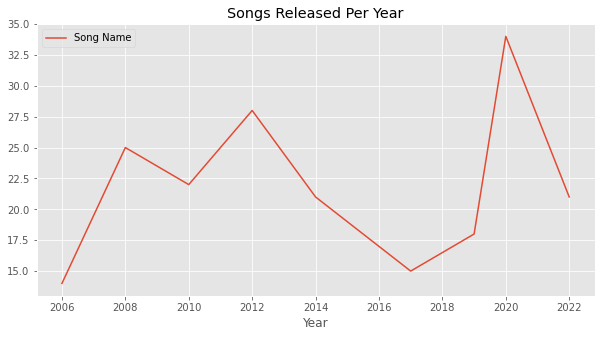

In [450]:
tswift.groupby('Year').count().get(['Song Name']).plot(kind='line', title='Songs Released Per Year');


In [451]:
year_with_most_songs = 2020
year_with_most_songs


2020

Identify the albums represented in the highest-volume year in this dataset.

In [453]:
sister_albums = tswift[tswift.get('Year')==2020].get('Album').unique()
sister_albums


array(['folklore', 'evermore'], dtype=object)

### Catalog size by album

Find the album with the largest number of represented tracks.

In [455]:
most_songs_album = tswift.groupby('Album').count().sort_values(by='Song Name', ascending=False).index[0]
most_songs_album


'Red'

### Popularity in the dataset snapshot

Identify the highest- and lowest-popularity tracks in the available data. These scores are historical and can change over time.

In [457]:
most_pop = tswift.sort_values(by='Popularity', ascending=False).iloc[0].get('Song Name')
least_pop = tswift.sort_values(by='Popularity', ascending=False).iloc[-1].get('Song Name')

print(f'The most popular Taylor Swift song right now is {most_pop}.')
print(f'The least popular Taylor Swift song right now is {least_pop}.')


The most popular Taylor Swift song right now is Cruel Summer.
The least popular Taylor Swift song right now is A Perfectly Good Heart.


### Maximum and median popularity by release year

Compare two summaries to distinguish peak track popularity from the typical track in each release-year group.

In [459]:
max_pop=tswift.groupby('Year').max()
tswift_max_pop=max_pop.assign(Max_Popularity=max_pop.get('Popularity')).get(['Max_Popularity'])
tswift_max_pop


,Max_Popularity
Year,
2006,77
2008,87
2010,88
2012,87
2014,92
2017,91
2019,99
2020,92
2022,93


In [460]:
med_pop=tswift.groupby('Year').median()
tswift_med_pop=med_pop.assign(Median_Popularity=med_pop.get('Popularity')).get(['Median_Popularity'])
tswift_med_pop


,Median_Popularity
Year,
2006,61.0
2008,69.0
2010,79.0
2012,73.5
2014,81.0
2017,82.0
2019,81.5
2020,74.0
2022,79.0


In [461]:
popularity_by_year = tswift_max_pop.merge(tswift_med_pop, left_index=True, right_index=True)
popularity_by_year


,Max_Popularity,Median_Popularity
Year,,
2006,77,61.0
2008,87,69.0
2010,88,79.0
2012,87,73.5
2014,92,81.0
2017,91,82.0
2019,99,81.5
2020,92,74.0
2022,93,79.0


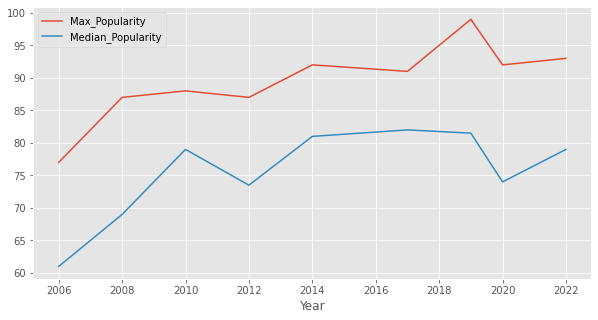

In [463]:
popularity_by_year.plot(kind='line');


### Loudness and energy

Visualize the relationship between loudness and energy and overlay a fitted line. This is an exploratory association, not a causal claim.

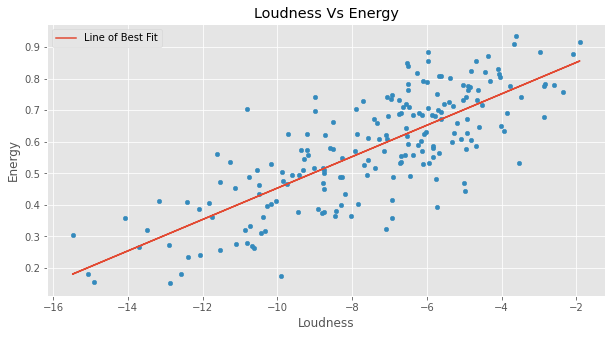

In [464]:
tswift.plot(kind='scatter',x='Loudness',y='Energy', title='Loudness Vs Energy')


x = tswift.get('Loudness')
y = tswift.get('Energy')
a, b = np.polyfit(x, y, 1)
plt.plot(x, a * x + b, label='Line of Best Fit')        
plt.legend()
plt.show()


### Valence and popularity

Explore whether Spotify's valence measure is associated with track popularity in this dataset.

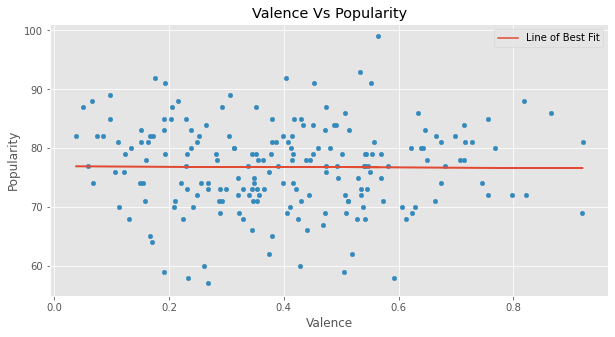

In [467]:
tswift.plot(kind='scatter',x='Valence',y='Popularity', title='Valence Vs Popularity')

x = tswift.get('Valence')
y = tswift.get('Popularity')
a, b = np.polyfit(x, y, 1)
plt.plot(x, a * x + b, label='Line of Best Fit')        
plt.legend()
plt.show()


### Valence distribution

Inspect the distribution of the audio-feature measure across the catalog.

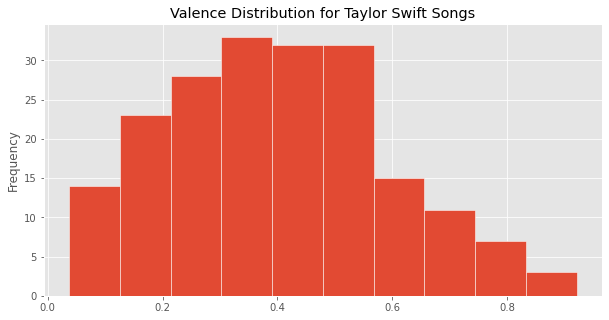

In [470]:
tswift.plot(kind='hist', x='Song Name', y='Valence', ec='w', legend=False, title='Valence Distribution for Taylor Swift Songs');


### Musical mode

The dataset encodes major keys as 1 and minor keys as 0. Audio examples illustrate the distinction; mode alone does not determine a song's emotional meaning.

In [473]:
play_spotify('3fthfkkvy9av3q3uAGVf7U')


A contrasting audio example from a track represented in a minor key.

In [474]:
play_spotify('1P17dC1amhFzptugyAO7Il')


### Minor-key tracks by album

Count tracks in minor keys, displaying albums with at least two such tracks.

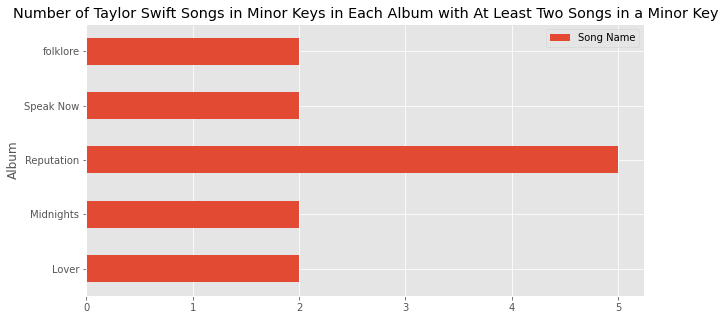

In [475]:
num_minor=tswift[tswift.get('Mode')==0].groupby('Album').count()
num_minor=num_minor[num_minor.get('Song Name')>=2]
num_minor.plot(kind='barh',y='Song Name', title='Number of Taylor Swift Songs in Minor Keys in Each Album with At Least Two Songs in a Minor Key');


### Ranking albums by mean audio features

Aggregate song-level features by album and return album names in descending order of the selected feature.

In [476]:
def sort_albums_by(feature):
    return np.array(tswift.groupby('Album').mean().get(feature).sort_values(ascending=False).index)

sort_albums_by('Energy')


array(['1989', 'Taylor Swift', 'Speak Now', 'Fearless', 'Red',
       'Reputation', 'Lover', 'evermore', 'Midnights', 'folklore'],
      dtype=object)

Compare rankings across the available audio features.

In [478]:
features = ['Popularity', 'Explicit', 'Danceability', 'Energy', 'Loudness',
            'Speechiness', 'Acousticness', 'Instrumentalness', 'Liveness',
            'Valence', 'Duration_ms', 'Tempo']

for feature in features:
    # These lines display the output nicely. You don't need to understand how they work.
    display(Markdown(f"Taylor Swift albums, in descending order of `'{feature}'`:"))
    display(Markdown("- " + ", ".join(sort_albums_by(feature))))


Taylor Swift albums, in descending order of `'Popularity'`:

- Reputation, Lover, 1989, Speak Now, Midnights, folklore, Red, evermore, Fearless, Taylor Swift

Taylor Swift albums, in descending order of `'Explicit'`:

- evermore, Midnights, folklore, Red, 1989, Fearless, Lover, Reputation, Speak Now, Taylor Swift

Taylor Swift albums, in descending order of `'Danceability'`:

...

- Lover, Red, evermore, Fearless, Taylor Swift, 1989, Speak Now, folklore, Reputation, Midnights

Taylor Swift albums, in descending order of `'Duration_ms'`:

- Speak Now, Red, Fearless, evermore, folklore, Reputation, 1989, Taylor Swift, Midnights, Lover

Taylor Swift albums, in descending order of `'Tempo'`:

- Fearless, Speak Now, Reputation, Taylor Swift, evermore, 1989, Lover, folklore, Red, Midnights

Inspect the album ranking by the proportion of tracks marked explicit. This flag does not measure the number of explicit words.

In [479]:
display(Markdown(f"Taylor Swift albums, in descending order of `'Explicit'`:"))
display(Markdown("- " + ", ".join(sort_albums_by('Explicit'))))


Taylor Swift albums, in descending order of `'Explicit'`:

- evermore, Midnights, folklore, Red, 1989, Fearless, Lover, Reputation, Speak Now, Taylor Swift

### Featured-artist tracks and solo tracks

Compare mean explicitness, danceability, and acousticness using the track-name featured-artist marker. This naming-based grouping may miss collaborations that use different labels.

In [486]:
tswift


,Album,Song Name,Disc Number,Track Number,Popularity,Explicit,Danceability,Energy,Key,Loudness,Mode,Speechiness,Acousticness,Instrumentalness,Liveness,Valence,Tempo,Duration_ms,Time Signature,Year
URI,,,,,,,,,,,,,,,,,,,,
1BxfuPKGuaTgP7aM0Bbdwr,Lover,Cruel Summer,1,2,99,False,0.552,0.702,9,-5.707,1,0.1570,0.11700,0.000021,0.1050,0.564,169.994,178427,4,2019
1dGr1c8CrMLDpV6mPbImSI,Lover,Lover,1,3,91,False,0.359,0.543,7,-7.582,1,0.0919,0.49200,0.000016,0.1180,0.453,68.534,221307,4,2019
3RauEVgRgj1IuWdJ9fDs70,Lover,The Man,1,4,86,False,0.777,0.658,0,-5.191,1,0.0540,0.07670,0.000000,0.0901,0.633,110.048,190360,4,2019
4y5bvROuBDPr5fuwXbIBZR,Lover,Paper Rings,1,8,86,False,0.811,0.719,9,-6.553,1,0.0497,0.01290,0.000014,0.0742,0.865,103.979,222400,4,2019
6RRNNciQGZEXnqk8SQ9yv5,Lover,You Need To Calm Down,1,14,84,False,0.771,0.671,2,-5.617,1,0.0553,0.00929,0.000000,0.0637,0.714,85.026,171360,4,2019
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6K0CJLVXqbGMeJSmJ4ENKK,Taylor Swift,Tied Together With A Smile,1,7,59,False,0.479,0.578,2,-4.963,1,0.0294,0.52500,0.000000,0.0841,0.192,146.165,248107,4,2006
2ZoOmCSgj0ypVAmGd1ve4y,Taylor Swift,Stay Beautiful,1,8,59,False,0.594,0.629,8,-4.919,1,0.0246,0.08680,0.000000,0.1370,0.504,131.597,236053,4,2006
2QA3IixpRcKyOdG7XDzRgv,Taylor Swift,The Outside,1,6,58,False,0.589,0.805,5,-4.055,1,0.0293,0.00491,0.000000,0.2400,0.591,112.982,207107,4,2006


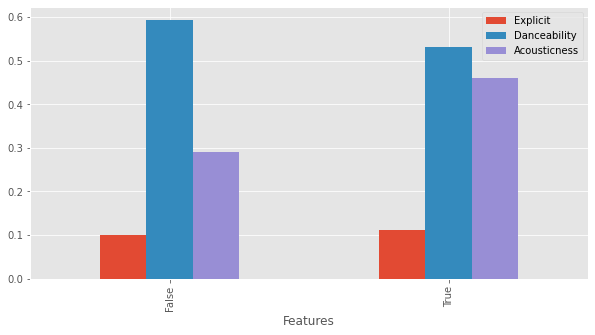

In [489]:
tswift_ft=tswift.assign(Features=tswift.get('Song Name').str.contains('Ft.'))
tswift_plot=tswift_ft.groupby('Features').mean()

tswift_plot.get(['Explicit', 'Danceability', 'Acousticness']).plot(kind='bar');


<a id="recommendations"></a>
## 3. Content-based song recommendations

Recommend Taylor Swift songs with audio features similar to a selected input track. This is an audio-feature similarity system rather than collaborative filtering or a model trained on listener preferences.

In [492]:
billions_club = bpd.read_csv('data/billions_club.csv').set_index('URI')
billions_club


,Album,Song Name,Artist,Disc Number,Track Number,Popularity,Explicit,Danceability,Energy,Key,Loudness,Mode,Speechiness,Acousticness,Instrumentalness,Liveness,Valence,Tempo,Duration_ms,Time Signature
URI,,,,,,,,,,,,,,,,,,,,
1dGr1c8CrMLDpV6mPbImSI,Lover,Lover,Taylor Swift,1,3,91,False,0.359,0.543,7,-7.582,1,0.0919,0.492000,0.000016,0.1180,0.453,68.534,221307,4
2QfznFotJNZmnIEYFdzE5T,Heartbreak Anniversary,Heartbreak Anniversary,Giveon,1,1,73,False,0.624,0.457,0,-8.876,1,0.0494,0.557000,0.000000,0.1280,0.586,129.758,196795,4
5XeFesFbtLpXzIVDNQP22n,AM,I Wanna Be Yours,Arctic Monkeys,1,12,95,False,0.464,0.417,0,-9.345,0,0.0256,0.136000,0.022000,0.0974,0.479,67.528,183956,4
2dHHgzDwk4BJdRwy9uXhTO,HEROES & VILLAINS,Creepin' (with The Weeknd & 21 Savage),Metro Boomin; The Weeknd; 21 Savage,1,10,92,True,0.715,0.620,1,-6.005,0,0.0484,0.417000,0.000000,0.0822,0.172,97.950,221520,4
5W8YXBz9MTIDyrpYaCg2Ky,Infest,Last Resort,Papa Roach,1,2,83,True,0.589,0.890,4,-3.719,0,0.0603,0.000481,0.000820,0.2010,0.692,90.598,199907,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3s4U7OHV7gnj42VV72eSZ6,Rather Be (feat. Jess Glynne),Rather Be (feat. Jess Glynne),Clean Bandit; Jess Glynne,1,1,75,False,0.799,0.586,11,-6.735,1,0.0377,0.162000,0.000002,0.1930,0.549,120.970,227833,4
6zeeWid2sgw4lap2jV61PZ,Suncity,Better,Khalid,1,6,75,False,0.596,0.552,0,-10.278,0,0.0970,0.076500,0.334000,0.1040,0.112,97.949,229320,4
2yPoXCs7BSIUrucMdK5PzV,Good Girl Gone Bad,Umbrella,Rihanna; JAY-Z,1,1,74,False,0.583,0.829,1,-4.603,1,0.1340,0.008640,0.000000,0.0426,0.575,174.028,275987,4


### Selecting an input track

Inspect a sample from the comparison-song catalog and choose a seed track for recommendations.

In [493]:
billions_club.sample(10).get(['Song Name', 'Artist'])


,Song Name,Artist
URI,,
1dGr1c8CrMLDpV6mPbImSI,Lover,Taylor Swift
6f3Slt0GbA2bPZlz0aIFXN,The Business,Tiësto
503OTo2dSqe7qk76rgsbep,Still D.R.E.,Dr. Dre; Snoop Dogg
3Wrjm47oTz2sjIgck11l5e,Beggin',Måneskin
285pBltuF7vW8TeWk8hdRR,Lucid Dreams,Juice WRLD
7KXjTSCq5nL1LoYtL7XAwS,HUMBLE.,Kendrick Lamar
1auxYwYrFRqZP7t3s7w4um,Ni**as In Paris,JAY-Z; Kanye West
2iuZJX9X9P0GKaE93xcPjk,Sugar,Maroon 5
003vvx7Niy0yvhvHt4a68B,Mr. Brightside,The Killers


The example seed track is **Viva La Vida**. Its Spotify URI identifies the row used for feature extraction.

In [494]:
favorite_uri = '1mea3bSkSGXuIRvnydlB5b'
favorite_song_name = 'Viva La Vida'

print(f'My favorite song is {favorite_song_name}. It has a URI of {favorite_uri}.')


My favorite song is Viva La Vida. It has a URI of 1mea3bSkSGXuIRvnydlB5b.


In [496]:
play_spotify(favorite_uri)


### Feature selection

The default feature set uses seven measures on a 0–1 scale: danceability, energy, speechiness, acousticness, instrumentalness, liveness, and valence. The recommendation functions also accept custom feature subsets.

In [497]:
default_features = [
    'Danceability', 
    'Energy',
    'Speechiness',
    'Acousticness',
    'Instrumentalness',
    'Liveness',
    'Valence'
]


### Extracting feature vectors

Look up a song by URI and return the selected numerical features as an array.

In [503]:
def get_feature_values(input_uri, song_df, feature_list):
    song_df_no_index = song_df.reset_index()  
    if input_uri in song_df_no_index.get('URI').values:
        song_df_filtered = song_df_no_index[song_df_no_index.get('URI') == input_uri]
        feature_values = np.array(song_df_filtered.get(feature_list).iloc[0])
        return feature_values
    else:
        print('This URI was not found.')
        return None
# Now call your function to extract some audio features of your favorite song.
get_feature_values(favorite_uri, billions_club, ['Danceability', 'Energy'])


array([0.486, 0.617])

### Measuring similarity

Calculate Euclidean distance between feature vectors. Smaller distances indicate greater similarity in the chosen feature space.

In [505]:
def calculate_similarity(features_1, features_2):
    index = np.arange (0, len (features_1))
    difference_array = []
    for i in index:
        difference = (features_1[i] - features_2[i])**2
        difference_array = np.append(difference_array,difference)
    difference_sum = (difference_array.sum())**(1/2)
    return difference_sum
favorite_vs_karma = calculate_similarity(get_feature_values(favorite_uri, billions_club, ['Danceability', 'Energy', 'Valence', 'Acousticness']),
                                                            get_feature_values('7KokYm8cMIXCsGVmUvKtqf', tswift.reset_index() , ['Danceability', 'Energy', 'Valence', 'Acousticness'])
                                        )
favorite_vs_karma


0.3567814597200925

### Comparing the input with the full catalog

Compute the distance from the selected song to each Taylor Swift track.

In [507]:
def calculate_similarity_for_all(input_uri, song_df, feature_list):
    features_input = get_feature_values (input_uri, song_df, feature_list)
    similarity_scores = []
    for i in np.arange(0, tswift.shape[0]):
        feature_add = get_feature_values (tswift.reset_index().get('URI').iloc[i], tswift, feature_list)
        similarity = calculate_similarity(features_input, feature_add)
        similarity_scores = np.append(similarity_scores, similarity)
    return similarity_scores

calculate_similarity_for_all(favorite_uri, billions_club, ['Danceability', 'Energy', 'Valence', 'Acousticness'])


array([0.18345724, 0.42449094, 0.36519541, 0.56880511, 0.42398695,
       0.23941337, 0.74201399, 0.32038283, 0.32107812, 0.4016961 ,
       0.27738536, 0.78288017, 0.45134351, 0.75295575, 0.48929233,
       0.42273841, 1.02050201, 0.92235815, 0.19526945, 0.35678146,
       0.69114627, 0.47140759, 0.43324515, 0.22101801, 0.31027691,
       0.46509114, 0.53243005, 0.23872779, 0.62755299, 0.72378046,
       0.99494571, 0.81590083, 0.43716377, 0.42353767, 0.89755076,
       0.25083772, 0.73584629, 0.52294202, 0.36601279, 0.27182163,
       0.36971091, 0.48635686, 0.27462079, 0.27570462, 0.4346422 ,
       0.36765981, 0.15622897, 0.41313431, 0.56451219, 0.38617862,
       0.44596677, 0.183493  , 0.24746871, 0.3347443 , 0.16880939,
       0.15054914, 0.3343001 , 0.318835  , 0.42577402, 0.53562576,
       0.44524461, 0.47999121, 0.79226306, 0.80623853, 0.63050738,
       0.85135443, 0.84769945, 0.26178801, 0.77952406, 0.57523487,
       0.51345161, 0.82226891, 0.85931517, 0.58226554, 0.90978

### Ranking recommendations

Sort candidate tracks by increasing distance and return the requested number of matches.

In [509]:
def select_top_recommendations(similarity_scores, n):
    tswift_similarity_scores = tswift.assign (similarity_scores = similarity_scores).reset_index()
    tswift_similarity_sorted = tswift_similarity_scores.sort_values(by = 'similarity_scores',)
    top_recs = tswift_similarity_sorted.iloc[np.arange(0, n)]
    top_reccomendations = top_recs.drop (columns = 'similarity_scores').set_index ('URI')
    return top_reccomendations


### Combining the recommendation pipeline

The recommender accepts an input URI, a source song table, the number of recommendations, and an optional feature list. It returns ranked tracks with their album, title, and selected features.

In [511]:
def song_recommender(input_uri, song_df, n, feature_list=default_features):
    top = select_top_recommendations (calculate_similarity_for_all(input_uri, song_df, feature_list), n)
    top_songs = top.get(['Album', 'Song Name']+ feature_list)
    return top_songs
# The following call to song_recommender finds the 5 Taylor Swift songs
# that are most similar to your chosen song, in terms of 'Danceability' and 'Energy'.
# We've also include a print statement to help you interpet the output.
print(f'Taylor Swift songs that are most similar to {favorite_song_name}:')
song_recommender(favorite_uri, billions_club, 5, ['Danceability', 'Energy'])


Taylor Swift songs that are most similar to Viva La Vida:


,Album,Song Name,Danceability,Energy
URI,,,,
7qEUFOVcxRI19tbT68JcYK,Red,Everything Has Changed (Ft. Ed Sheeran),0.498,0.610
79uDOz0zuuWS7HWxzMmTa2,Speak Now,Back To December,0.497,0.635
7HC7R2D8WjXVcUHJyEGjRs,Fearless,Breathe (Ft. Colbie Caillat),0.506,0.626
4pNApnaUWAL2J4KO2eqokq,Red,Come Back...Be Here,0.460,0.632
6K0CJLVXqbGMeJSmJ4ENKK,Taylor Swift,Tied Together With A Smile,0.479,0.578


### Interactive recommendation interface

The course-provided display helpers connect the recommendation functions to a dropdown and Spotify embeds. The interface requires a running notebook; saved output is not a standalone web application.

In [516]:
default = 'Bank Account by 21 Savage'

def get_and_format_recommendations(song_name):
    song, artist = song_name.split(' by ')
    row = billions_club[(billions_club.get('Song Name') == song) & (billions_club.get('Artist') == artist)]
    uri = row.index[0]
    recommendations_df = song_recommender(uri, billions_club, 5, default_features)
    display(HTML(f'<h3>The song you chose was {billions_club.get("Song Name").loc[uri]} by {billions_club.get("Artist").loc[uri]}.</h3>'))
    play_spotify(uri)
    display(HTML('<h4>Here are the 5 most similar Taylor Swift songs we found.</h4>'))
    for recommended_uri in recommendations_df.index:
        play_spotify(recommended_uri)

song_options = np.sort(billions_club.get('Song Name') + ' by ' + billions_club.get('Artist'))
song_widget = widgets.Dropdown(options=song_options, description='Song', layout={'width': '525px'}, value=default)
   
def change_rec(change):
    if change['name'] == 'value' and change['new'] != change['old']:
        clear_output()
        display(song_widget)
        get_and_format_recommendations(song_widget.value)

display(song_widget)
get_and_format_recommendations(default)
song_widget.observe(change_rec)


Dropdown(description='Song', index=26, layout=Layout(width='525px'), options=('1-800-273-8255 by Logic; Alessi…

### Finding a similar pair within the catalog

Explore the closest pair under a selected set of features, excluding each song's match with itself.

In [517]:
def most_similar_pair(feature_list=default_features):
    # Initialize an empty array to store the most similar pair of songs.
    # Instead, when you find a pair of songs that's more similar than the"most similar pair" 
    # you've ever seen, you'll update this array to contain those two songs instead.
    pair_of_songs = np.array([])
    
    # Any time you find a pair of songs that's more similar than any pair you've ever seen,
    # you should update this variable. We initialize it to 1.01 because the maximum possible
    # similarity score is 1, so we know that this variable will be updated in the first iteration
    # of the for-loop, corresponding to the most similar pair of songs we've seen so far.
    lowest_similarity_score_seen = 1.01
    
    # Loop over the URIs of Taylor Swift's songs.
    for uri in tswift.index:
        # Calculate similarities between this song and all other Taylor Swift songs.
        similarities = calculate_similarity_for_all(uri, tswift, feature_list)
        
        # Add the array of similarity scores as a column to tswift.
        # Sort the rows so that the most similar songs are at the top.
        with_similarities = tswift.assign (similarities = similarities).reset_index().sort_values(by = 'similarities', ascending = True)
        
        # Every song will have a similarity score (distance) of 0 with itself,
        # so if we just take the smallest similarity score, we'll end up with two of the same song. 
        # Take the second-smallest similarity to account for this.
        current_lowest_similarity_score = with_similarities.get('similarities').iloc[1]
        
        if current_lowest_similarity_score < lowest_similarity_score_seen: 
            # Update the lowest_similarity_score_seen and pair_of_songs variables.
            # Make sure to get the names of the songs from the with_similarities DataFrame.
            lowest_similarity_score_seen = current_lowest_similarity_score
            song_1 = with_similarities[with_similarities.get('URI') == uri].get('Song Name')
            song_2 = with_similarities.get('Song Name').iloc[1]
            
    pair_of_songs = np.append (pair_of_songs, song_1)
    pair_of_songs = np.append (pair_of_songs, song_2)
            
    return pair_of_songs

# It's totally fine if it takes up to a minute to run each function call.
most_similar_dance_acoustic = most_similar_pair(['Danceability', 'Acousticness'])
most_similar_dance_acoustic


array(['Getaway Car', "I'm Only Me When I'm With You"], dtype=object)

Play the selected pair to compare the numerical match with listening impressions.

In [520]:
name_1, name_2 = most_similar_pair()
uri_1 = tswift[tswift.get('Song Name') == name_1].index[0]
uri_2 = tswift[tswift.get('Song Name') == name_2].index[0]
play_spotify(uri_1) 
play_spotify(uri_2)


### Recommendations from a Taylor Swift seed track

A second notebook interface uses Taylor Swift songs as inputs and presents the five closest tracks.

In [522]:
default_tswift = 'Enchanted, from the album Speak Now'

def get_and_format_recommendations_tswift(song_name):
    song, album = song_name.split(', from the album ')
    
    row = tswift[(tswift.get('Song Name') == song)]
    uri = row.index[0]
    recommendations_df = song_recommender(uri, tswift, 6, default_features)
    display(HTML(f'<h3>The song you chose was {tswift.get("Song Name").loc[uri]}, from the album {tswift.get("Album").loc[uri]}.</h3>'))
    play_spotify(recommendations_df.index[0])
    display(HTML('<h4>Here are the 5 most similar <b>other</b> Taylor Swift songs we found.</h4>'))
    for recommended_uri in recommendations_df.index[1:]:
        play_spotify(recommended_uri)

by_album = tswift.sort_values(['Album', 'Disc Number', 'Track Number'])
song_options_tswift = np.array(by_album.get('Song Name') + ', from the album ' + by_album.get('Album'))
song_widget_tswift = widgets.Dropdown(options=song_options_tswift, description='Song', layout={'width': '525px'}, value=default_tswift)
   
def change_rec_tswift(change):
    if change['name'] == 'value' and change['new'] != change['old']:
        clear_output()
        display(song_widget_tswift)
        get_and_format_recommendations_tswift(song_widget_tswift.value)

display(song_widget_tswift)
get_and_format_recommendations_tswift(default_tswift)
song_widget_tswift.observe(change_rec_tswift)


Dropdown(description='Song', index=136, layout=Layout(width='525px'), options=('Welcome To New York, from the …

<a id="lyric-search"></a>
## 4. Lyric search

Search for phrases across songs without distinguishing upper- and lowercase text, then display matching lines with neighboring context and track information.

In [524]:
lyrics


,Album,Lyrics
Song,,
Anti-Hero,Midnights,"I have this thing where I get older, but just ..."
Bejeweled,Midnights,"Baby love, I think I've been a little too kind..."
Bigger Than The Whole Sky,Midnights,No words appear before me in the aftermath\nSa...
Dear Reader,Midnights,"Dear reader, if it feels like a trap\nYou're a..."
Glitch,Midnights,We were supposed to be just friends\nYou don't...
...,...,...
Stay Beautiful,Taylor Swift,"Cory's eyes are like a jungle\nHe smiles, it's..."
Teardrops On My Guitar,Taylor Swift,Drew looks at me\nI fake a smile so he won't s...
The Outside,Taylor Swift,I didn't know what I would find\nWhen I went l...


### Exact phrase matching

Start with a phrase filter over the lyric table.

In [525]:
casually_cruel = lyrics[lyrics.get('Lyrics').str.contains('casually cruel')]
casually_cruel


,Album,Lyrics
Song,,
All Too Well (10 Minute Version),Red,"I walked through the door with you, the air wa..."


### Handling capitalization

Inspect an example that illustrates why case-sensitive matching can omit relevant songs.

In [527]:
# Why is Mr. Perfectly Fine not included? 
print(lyrics.get('Lyrics').loc['Mr. Perfectly Fine'])


Mr. "Perfect face"
Mr. "Here to stay"
Mr. "Looked me in the eye and told me you would never go away"
Everything was right
Mr. "I've been waitin' for you all my life"
Mr. "Every single day until the end, I will be by your side"

But that was when I got to know Mr. "Change of heart"
Mr. "Leaves me all alone," I fall apart
It takes everything in me just to get up each day
But it's wonderful to see that you're okay

Hello, Mr. "Perfectly fine"
How's your heart after breakin' mine?
Mr. "Always at the right place at the right time," baby
Hello, Mr. "Casually cruel"
Mr. "Everything revolves around you"
I've been Miss Misery since your goodbye
And you're Mr. "Perfectly fine"

Mr. "Never told me why"
Mr. "Never had to see me cry"
Mr. "Insincere apology so he doesn't look like the bad guy"
He goes about his day
Forgets he ever even heard my name
Well, I thought you might be different than the rest, I guess you're all the same

'Cause I hear he's got his arm 'round a brand-new girl
I've been pick

Normalize the search text and lyrics to lowercase before filtering. The implementation uses string-pattern matching; literal punctuation-heavy searches may need additional handling.

In [528]:
lyrics_new = lyrics.assign(Lyrics_lowercase=lyrics.get('Lyrics').str.lower())
lyrics_new


,Album,Lyrics,Lyrics_lowercase
Song,,,
Anti-Hero,Midnights,"I have this thing where I get older, but just ...","i have this thing where i get older, but just ..."
Bejeweled,Midnights,"Baby love, I think I've been a little too kind...","baby love, i think i've been a little too kind..."
Bigger Than The Whole Sky,Midnights,No words appear before me in the aftermath\nSa...,no words appear before me in the aftermath\nsa...
Dear Reader,Midnights,"Dear reader, if it feels like a trap\nYou're a...","dear reader, if it feels like a trap\nyou're a..."
Glitch,Midnights,We were supposed to be just friends\nYou don't...,we were supposed to be just friends\nyou don't...
...,...,...,...
Stay Beautiful,Taylor Swift,"Cory's eyes are like a jungle\nHe smiles, it's...","cory's eyes are like a jungle\nhe smiles, it's..."
Teardrops On My Guitar,Taylor Swift,Drew looks at me\nI fake a smile so he won't s...,drew looks at me\ni fake a smile so he won't s...
The Outside,Taylor Swift,I didn't know what I would find\nWhen I went l...,i didn't know what i would find\nwhen i went l...


In [529]:
def phrase_match_df(phrase):
    return lyrics_new[lyrics_new.get('Lyrics_lowercase').str.contains(phrase.lower())].drop(columns='Lyrics_lowercase')
phrase_match_df('casually cruel')


,Album,Lyrics
Song,,
All Too Well (10 Minute Version),Red,"I walked through the door with you, the air wa..."
Mr. Perfectly Fine,Fearless,"Mr. ""Perfect face""\nMr. ""Here to stay""\nMr. ""L..."


In [531]:
print(mastermind)


Once upon a time, the planets and the fates
And all the stars aligned
You and I ended up in the same room
At the same time

And the touch of a hand lit the fuse
Of a chain reaction of countermoves
To assess the equation of you
Checkmate, I couldn't lose

What if I told you none of it was accidental?
And the first night that you saw me
Nothing was gonna stop me
I laid the groundwork, and then
Just like clockwork
The dominoes cascaded in a line
What if I told you I'm a mastermind?
And now you're mine
It was all by dеsign
'Cause I'm a mastermind

You see, all the wisеst women
Had to do it this way
'Cause we were born to be the pawn
In every lover's game

If you fail to plan, you plan to fail
Strategy sets the scene for the tale
I'm the wind in our free-flowing sails
And the liquor in our cocktails

What if I told you none of it was accidental?
And the first night that you saw me
I knew I wanted your body
I laid the groundwork, and then
Just like clockwork
The dominoes cascaded in a line
W

### Splitting lyrics into lines

Split a song's text on newline characters to support line-level results.

In [532]:
fine_lines = lyrics.get('Lyrics').loc['Mr. Perfectly Fine'].split('\n')
fine_lines


['Mr. "Perfect face"',
 'Mr. "Here to stay"',
 'Mr. "Looked me in the eye and told me you would never go away"',
 'Everything was right',
 'Mr. "I\'ve been waitin\' for you all my life"',
 'Mr. "Every single day until the end, I will be by your side"',
 '',
 'But that was when I got to know Mr. "Change of heart"',
 'Mr. "Leaves me all alone," I fall apart',
 'It takes everything in me just to get up each day',
 "But it's wonderful to see that you're okay",
 '',
 'Hello, Mr. "Perfectly fine"',
 "How's your heart after breakin' mine?",
 'Mr. "Always at the right place at the right time," baby',
 'Hello, Mr. "Casually cruel"',
 'Mr. "Everything revolves around you"',
 "I've been Miss Misery since your goodbye",
 'And you\'re Mr. "Perfectly fine"',
 '',
 'Mr. "Never told me why"',
 'Mr. "Never had to see me cry"',
 'Mr. "Insincere apology so he doesn\'t look like the bad guy"',
 'He goes about his day',
 'Forgets he ever even heard my name',
 "Well, I thought you might be different than th

Collect matching lines for an example phrase.

In [534]:
phrase = 'casually cruel'
cruel_fine_lines = np.array([])
for line in fine_lines:
    if phrase.lower() in line.lower():
        cruel_fine_lines=np.append(cruel_fine_lines,line)
cruel_fine_lines


array(['Hello, Mr. "Casually cruel"', 'Hello, Mr. "Casually cruel"',
       'Goodbye, Mr. "Casually cruel"'], dtype='<U32')

### Generalizing line matching

Return matching lines for any song and phrase.

In [536]:
def isolate_phrase(song_title, phrase):
    general_lyrics=lyrics.get('Lyrics').loc[song_title].split('\n')
    search_lyrics= np.array([])
    for i in general_lyrics:
        if phrase.lower() in i.lower():
            search_lyrics=np.append(search_lyrics,i)
    return search_lyrics


isolate_phrase('Mastermind', 'plan')


array(['Once upon a time, the planets and the fates',
       'If you fail to plan, you plan to fail'], dtype='<U43')

### Adding surrounding context

Include neighboring lines to make each phrase match easier to interpret.

Handle first-line, last-line, and interior matches when collecting context.

In [538]:
def surround_phrase(song_title, phrase):
    line=lyrics.get('Lyrics').loc[song_title].split('\n')
    search_lyrics= np.array([])
    
    if phrase.lower() in line[0].lower():
        search_lyrics=np.append(search_lyrics, line[0])
        search_lyrics=np.append(search_lyrics, line[1])
    
    
    for i in np.arange(len(line)-2):
        if phrase.lower() in line[i+1].lower():
            search_lyrics=np.append(search_lyrics, line[i])
            search_lyrics=np.append(search_lyrics, line[i+1])
            search_lyrics=np.append(search_lyrics, line[i+2])
    
    if phrase.lower() in line[-1].lower():       
        search_lyrics=np.append(search_lyrics,line[-2])
        search_lyrics=np.append(search_lyrics, line[-1])
                
               
    return search_lyrics


surround_phrase('Mastermind', 'time')


array(['Once upon a time, the planets and the fates',
       'And all the stars aligned', 'You and I ended up in the same room',
       'At the same time', '',
       'To make them love me and make it seem effortless',
       "This is the first time I've felt the need to confess",
       'And I swear', 'Saw a wide smirk on your face',
       'You knew the entire time', "You knew that I'm a mastermind"],
      dtype='<U52')

### Including song and album labels

Append track information so that search results can be traced to their source song.

In [540]:
lyrics


,Album,Lyrics
Song,,
Anti-Hero,Midnights,"I have this thing where I get older, but just ..."
Bejeweled,Midnights,"Baby love, I think I've been a little too kind..."
Bigger Than The Whole Sky,Midnights,No words appear before me in the aftermath\nSa...
Dear Reader,Midnights,"Dear reader, if it feels like a trap\nYou're a..."
Glitch,Midnights,We were supposed to be just friends\nYou don't...
...,...,...
Stay Beautiful,Taylor Swift,"Cory's eyes are like a jungle\nHe smiles, it's..."
Teardrops On My Guitar,Taylor Swift,Drew looks at me\nI fake a smile so he won't s...
The Outside,Taylor Swift,I didn't know what I would find\nWhen I went l...


In [541]:
def one_song_search(song_title, phrase):
    line=lyrics.get('Lyrics').loc[song_title].split('\n')
    search_lyrics= np.array([])
    album=lyrics.get('Album').loc[song_title]
    
    
    if phrase.lower() in line[0].lower():
        search_lyrics=np.append(search_lyrics, line[0])
        search_lyrics=np.append(search_lyrics, line[1])
        search_lyrics=np.append(search_lyrics, song_title+ ', ' + album)
    
    
    for i in np.arange(len(line)-2):
        if phrase.lower() in line[i+1].lower():
            search_lyrics=np.append(search_lyrics, line[i])
            search_lyrics=np.append(search_lyrics, line[i+1])
            search_lyrics=np.append(search_lyrics, line[i+2])
            search_lyrics=np.append(search_lyrics, song_title+ ', ' + album)
    
    if phrase.lower() in line[-1].lower():       
        search_lyrics=np.append(search_lyrics,line[-2])
        search_lyrics=np.append(search_lyrics, line[-1])
        search_lyrics=np.append(search_lyrics, song_title+ ', ' + album)
                
               
    return search_lyrics
    
one_song_search('Mastermind', 'time')


array(['Once upon a time, the planets and the fates',
       'And all the stars aligned', 'Mastermind, Midnights',
       'You and I ended up in the same room', 'At the same time', '',
       'Mastermind, Midnights',
       'To make them love me and make it seem effortless',
       "This is the first time I've felt the need to confess",
       'And I swear', 'Mastermind, Midnights',
       'Saw a wide smirk on your face', 'You knew the entire time',
       "You knew that I'm a mastermind", 'Mastermind, Midnights'],
      dtype='<U52')

### Searching across songs

Collect results across every song containing an example phrase.

In [543]:
fifteen_songs = phrase_match_df('fifteen')
fifteen_array = np.array([])
song= fifteen_songs.index

for i in song:
    fifteen_array = np.append(fifteen_array, one_song_search(i,'fifteen'))


fifteen_array


array(["And every single one of your friends was makin' fun of you",
       "But fifteen seconds later, thеy were clappin' too?",
       'Then what did you do?', 'Question...?, Midnights',
       "And every single one of your friends was makin' fun of you",
       "But fifteen seconds later, they were clappin' too?",
       'Then what did you do?', 'Question...?, Midnights',
       "And every single one of your friends was makin' fun of you (Makin' fun of you)",
       "But fifteen seconds later, they were clappin' too?",
       'Then what did you do? (Do)', 'Question...?, Midnights', '',
       'Fifteen years, fifteen million tears',
       "Begging 'til my knees bled", "it's time to go, evermore", '',
       'Good thing my daddy made me get a boating license when I was fifteen',
       "And I've cleaned enough houses to know how to cover up a scene",
       'no body, no crime (Ft. HAIM), evermore', '',
       'In the fifteen hundreds off in a foreign land',
       'And I was forced t

Generalize the cross-song search into a reusable function.

In [545]:
def search_for(phrase):
    search_array = np.array([])
    for i in phrase_match_df(phrase).index:
        search_array = np.append(search_array, one_song_search(i,phrase))
    return search_array    

# Make sure to try some other words and phrases.
search_for('fifteen')


array(["And every single one of your friends was makin' fun of you",
       "But fifteen seconds later, thеy were clappin' too?",
       'Then what did you do?', 'Question...?, Midnights',
       "And every single one of your friends was makin' fun of you",
       "But fifteen seconds later, they were clappin' too?",
       'Then what did you do?', 'Question...?, Midnights',
       "And every single one of your friends was makin' fun of you (Makin' fun of you)",
       "But fifteen seconds later, they were clappin' too?",
       'Then what did you do? (Do)', 'Question...?, Midnights', '',
       'Fifteen years, fifteen million tears',
       "Begging 'til my knees bled", "it's time to go, evermore", '',
       'Good thing my daddy made me get a boating license when I was fifteen',
       "And I've cleaned enough houses to know how to cover up a scene",
       'no body, no crime (Ft. HAIM), evermore', '',
       'In the fifteen hundreds off in a foreign land',
       'And I was forced t

### Formatting results and counting matches

Display labeled results and calculate phrase usages and the number of distinct matching songs.

In [547]:
def search_and_display(phrase, to_display=True):
    # Ignore the optional to_display argument.
    # By default, we will display all of the lyrics as done in search_for.
    
    match_array = search_for(phrase) 
    
    num_usages = 0
    matching_songs = np.array([])
    
    for line in match_array:
        
        # If the line represents a song name and album name, display it nicely.
        if line in np.array(lyrics.reset_index().get('Song') + ", " + lyrics.reset_index().get('Album')):
            if to_display:
                display(HTML(f'<center><b><i>{line}</i></b></center>')) # Display song and album names in bold italics.
                display(Markdown('___')) # Add horizontal line between matches.
            
            matching_songs = np.append(matching_songs, line)
        
        # Otherwise, if the line is not blank, print it.
        elif len(line) > 0:
            if to_display:
                display(HTML(f'<center>{line}</center>'))
            
            num_usages = num_usages + line.lower().count(phrase.lower())
            
    output_list = [num_usages, len(np.unique(matching_songs))]
    
    if to_display:
                display(HTML('<h3><center><span style="color:#888">Found ' + str(output_list[0]) + ' usages of \"' + phrase + '\" across ' + str(output_list[1]) + ' songs.</span></center></h3>'))
    return output_list 

fifteen_stats = search_and_display('fifteen')


___

___

___

___

___

...

___

___

___

___

___

### Interactive phrase-search interface

A notebook text widget connects user input to the search functions. The display code is supplied course scaffolding.

In [549]:
default_lyric = 'casually cruel'

lyric_box = widgets.Text(
    value=default_lyric,
    placeholder='Type a phrase here and hit enter.',
    description='Phrase:',
    layout={'width': '525px'},
    disabled=False   
)

def change_matches(change):
    clear_output()
    display(lyric_box)
    search_and_display(lyric_box.value)

display(lyric_box)
search_and_display(default_lyric)
lyric_box.on_submit(change_matches)


Text(value='casually cruel', description='Phrase:', layout=Layout(width='525px'), placeholder='Type a phrase h…

___

___

___

___

### Search coverage

Results depend on the songs and lyric versions in the dataset. Capitalization, punctuation, and repeated context lines can affect matching or counts; these require further checks before treating the tool as a production search system.

<a id="keywords"></a>
## 5. Keyword analysis

Use term frequency–inverse document frequency (TF-IDF) to identify words that distinguish songs on the album *Lover*.

In [ ]:
play_spotify('1LLXZFeAHK9R4xUramtUKw')


### Selecting the album corpus

Filter the lyric table to the *Lover* album.

In [550]:
lover_df = lyrics[lyrics.get('Album')=='Lover']
lover_df


,Album,Lyrics
Song,,
Afterglow,Lover,"I blew things out of proportion, now you're bl..."
Cornelia Street,Lover,We were in the backseat\nDrunk on something st...
Cruel Summer,Lover,"(Yeah, yeah, yeah, yeah)\n\nFever dream high i..."
Daylight,Lover,My love was as cruel as the cities I lived in\...
Death By A Thousand Cuts,Lover,"My, my, my, my\nMy, my, my, my\nMy, my, my, my..."
...,...,...
Paper Rings,Lover,The moon is high\nLike your friends were the n...
Soon You'll Get Better (Ft. The Chicks),Lover,The buttons of my coat were tangled in my hair...
The Archer,Lover,"Combat, I'm ready for combat\nI say I don't wa..."


### Tokenizing the lyrics

Convert lyric text to lowercase and split it into words.

In [552]:
unique_words_raw = np.array(lover_df.get('Lyrics').str.strip('\n').str.lower().str.split().sum())
unique_words_raw


array(['i', 'blew', 'things', ..., 'to', 'calm', 'down'], dtype='<U17')

Inspect punctuation variants before normalization.

In [554]:
'for' in unique_words_raw and '"for' in unique_words_raw


True

### Normalizing punctuation

Apply the implemented punctuation-cleaning function to reconcile selected token variants.

In [555]:
def drop_punctuation(word):
    resulting_word = (word.strip('\\').replace('(','').replace(')','').replace('?','').replace('.','')
                      .replace(',','').replace(';','').replace('-','').replace('_','').replace('"' , "'").strip("'"))
    return resulting_word


Collect unique normalized words for the album.

In [557]:
unique_words = []
for word in unique_words_raw:
    new_word = drop_punctuation(word)
    if new_word in unique_words:
        continue 
    else:     
        unique_words = np.append (unique_words, new_word)
unique_words


array(['i', 'blew', 'things', ..., 'figured', 'crowns', 'gowns'],
      dtype='<U32')

### TF-IDF

Term frequency measures a word's share of a song's word count. Inverse document frequency is the logarithm of the number of songs divided by the number containing the word. Their product emphasizes terms frequent in one song but less widespread across the album.

### Word-count matrix

Load word counts with one row per word and one column per song.

In [559]:
counts_df = bpd.read_csv('data/word_counts.csv').set_index('word')
counts_df


,Afterglow,Cornelia Street,Cruel Summer,Daylight,Death By A Thousand Cuts,False God,I Forgot That You Existed,I Think He Knows,It's Nice To Have A Friend,London Boy,Lover,ME! (Ft. Brendon Urie of Panic! At The Disco),Miss Americana & The Heartbreak Prince,Paper Rings,Soon You'll Get Better (Ft. The Chicks),The Archer,The Man,You Need To Calm Down
word,,,,,,,,,,,,,,,,,,
16th,0,0,0,0,0,0,0,4,0,0,0,0,0,0,0,0,0,0
17,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0
7,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1
a,1,3,11,3,14,7,2,3,8,14,4,11,9,3,2,2,15,5
about,0,0,0,0,0,2,0,0,0,0,1,1,0,0,1,0,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
you'll,0,0,1,0,0,0,0,0,0,0,1,5,0,0,12,0,0,0
you're,2,0,4,0,3,4,0,0,0,0,5,5,0,14,0,0,2,6
you've,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0


Calculate TF-IDF components for an example word–song pair.

In [560]:
counts_df_reset_index = counts_df.reset_index()
tf_numerator_about = counts_df.loc['about'].get('You Need To Calm Down')
tf_denominator_about = counts_df.get('You Need To Calm Down').sum()
idf_numerator_about = counts_df.shape[1]
idf_denominator_about = (counts_df.loc['about'] >0).sum()
tfidf_about = (tf_numerator_about / tf_denominator_about) * np.log(idf_numerator_about / idf_denominator_about) 
tfidf_about


0.0030517008018558604

Calculate inverse document frequency for all words. IDF depends on the album corpus rather than on one song.

In [562]:
idf_array = np.array([])
word_array = counts_df.index
# Loop through each word and compute the IDF of that word.
for word in word_array:
    idf_numerator = counts_df.shape[1]
    idf_denominator = (counts_df.loc[word] > 0).sum()
    idf = np.log(idf_numerator / idf_denominator) 
    idf_array = np.append(idf_array, idf)
idf_array
# Display the resulting array of IDF values.
idf_array


array([2.89037176, 2.89037176, 2.89037176, ..., 2.89037176, 0.3254224 ,
       2.19722458])

### Scoring all word–song pairs

Combine song-specific term frequencies with the IDF array to construct the TF-IDF table.

In [564]:
# Create a new empty DataFrame to store TF-IDF values.
every_tfidf = bpd.DataFrame()

# Create an array with the names of all songs on the Lover album.
songs_array = np.array(counts_df.columns)

# Loop through the songs, and for each song, compute a Series of TF-IDF values for each word.
for song in songs_array:
    # Assign tf_numerators to a Series of the numerators of the TF values of each word, for this song.
    tf_numerators = counts_df.get(song)
    
    # Assign tf_denominator to the denominator of all TF values, for this song. 
    # Note that this is a single number, not a Series or array.
    # We use the same denominator when calculating the TF of each word, for this song.
    tf_denominator = counts_df.get(song).sum()
    
    # Assign tfs to a Series of the TF values of each word, for this song.
    tfs = tf_numerators/tf_denominator
    
    # Assign tfidfs to a Series of the TF-IDF values of each word, for this song.
    # Remember that you've already calculated the IDF of each word, so use those values here.
    tfidfs = tfs*idf_array
    
    # Add a new column to the DataFrame every_tfidf.
    # The column name is the song title and the contents are the values in tfidfs.
    # Don't worry about how the line of code below works.
    every_tfidf = every_tfidf.assign(**{song: tfidfs})

every_tfidf


,Afterglow,Cornelia Street,Cruel Summer,Daylight,Death By A Thousand Cuts,False God,I Forgot That You Existed,I Think He Knows,It's Nice To Have A Friend,London Boy,Lover,ME! (Ft. Brendon Urie of Panic! At The Disco),Miss Americana & The Heartbreak Prince,Paper Rings,Soon You'll Get Better (Ft. The Chicks),The Archer,The Man,You Need To Calm Down
word,,,,,,,,,,,,,,,,,,
16th,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.028268,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.000000
17,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.007067,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.000000
7,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.008029
a,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.000000
about,0.000000,0.000000,0.000000,0.000000,0.000000,0.006278,0.000000,0.000000,0.000000,0.000000,0.004069,0.002210,0.0,0.000000,0.004342,0.000000,0.002328,0.003052
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
you'll,0.000000,0.000000,0.003120,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.005571,0.015132,0.0,0.000000,0.071340,0.000000,0.000000,0.000000
you're,0.003381,0.000000,0.005752,0.000000,0.004560,0.007922,0.000000,0.000000,0.000000,0.000000,0.012836,0.006973,0.0,0.018953,0.000000,0.000000,0.002937,0.011552
you've,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.017624,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.000000


Check that the table reproduces the earlier example calculation.

In [566]:
every_tfidf.get('You Need To Calm Down').loc['about'] == tfidf_about


True

### Ranking keywords

Return the ten highest-scoring words for an example song.

In [567]:
top_10_summer = np.array(every_tfidf.sort_values(by = 'Cruel Summer', ascending = False).index
                         .take(np.arange(0, 10)))
top_10_summer


array(['summer', 'woahoh', 'cruel', 'roll', 'yeah', 'ooh', 'waiting',
       'shape', 'breakable', 'keep'], dtype=object)

Generalize keyword ranking to any song in the *Lover* corpus.

In [570]:
def ten_keywords(song_name):
    top_10 = np.array(every_tfidf.sort_values(by = song_name, ascending = False).index
                         .take(np.arange(0, 10)))
    return top_10
# Here's one sample call, but try some more!
ten_keywords('London Boy')


array(['fancy', 'london', 'boy', 'ooh', 'love', 'mates', 'child', 'likes',
       'rumors', 'took'], dtype=object)

### Word-cloud display

A course-provided word-cloud interface visualizes lyric word frequencies. It is separate from the TF-IDF keyword ranking above and uses the original heart-mask image asset.

Dropdown(description='Song', index=6, layout=Layout(width='525px'), options=('Afterglow', 'Cornelia Street', '…

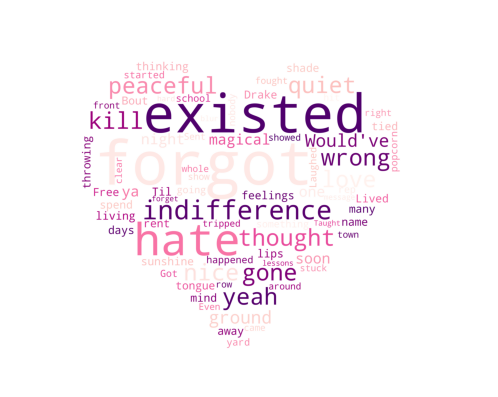

In [572]:
# We need to import some packages to make word clouds.
from wordcloud import WordCloud
from PIL import Image

# This function creates a word cloud for a given song.
def generate_lyrics_wordcloud(song_name):
    cloud = WordCloud(scale=3,
                      max_words=150,
                      colormap='RdPu',
                      mask=np.array(Image.open('data/images/heart.jpeg')),
                      background_color='white',
                      collocations=False).generate(lover_df.get('Lyrics').loc[song_name])
    plt.figure(figsize=(7, 5), dpi=100)
    plt.imshow(cloud)
    plt.axis('off')
    plt.show()

default_lover = 'I Forgot That You Existed'

song_options_lover = np.array(lover_df.index)
song_widget_lover = widgets.Dropdown(options=song_options_lover, description='Song', layout={'width': '525px'}, value=default_lover)

def change_rec_lover(change):
    if change['name'] == 'value' and change['new'] != change['old']:
        clear_output()
        display(song_widget_lover)
        display(HTML('Note: It may take a few seconds for the updated word cloud to appear.'))
        generate_lyrics_wordcloud(song_widget_lover.value)

display(song_widget_lover)
generate_lyrics_wordcloud(default_lover)
song_widget_lover.observe(change_rec_lover)


<a id="limitations"></a>
## 6. Limitations and next steps

- Audio-feature similarity is a proxy for musical similarity; it does not establish listener preference or recommendation quality.
- The default features share a 0–1 range, but custom feature combinations may require scaling or weighting.
- The recommender uses a fixed catalog snapshot and has no reported held-out ranking evaluation or user experiment.
- Lyric phrase matching and occurrence counting need further checks for punctuation, regular-expression behavior, and overlapping contexts.
- TF-IDF keywords depend on the chosen album corpus; the word cloud uses raw lyric text rather than the TF-IDF scores.

Potential extensions include comparing distance metrics, evaluating recommendations with listeners, making lyric matching literal and robust, and separating the notebook functions into a reusable application.

## Data, tools, and credits

**Tools:** Python, BabyPandas, NumPy, Matplotlib, IPython, ipywidgets, WordCloud, and Pillow.

**Required local files:** `data/lyrics.csv`, `data/tswift.csv`, `data/albums.csv`, `data/billions_club.csv`, `data/word_counts.csv`, and `data/images/heart.jpeg`. These files were not supplied with this portfolio copy. Keep their original relative paths when running the notebook.

**Team and course attribution:** Completed by Supriyaa Chordia and Siya Jatia as a UC San Diego DSC 10 project. Original course scaffolding and supplied interface helpers have been retained where needed; analytical explanations were edited for portfolio presentation.

**Original project references:**

- Spotify API — audio-feature and song data.
- Genius API — lyric data.
- Shayna Kothari, [Taylor Swift Lyric Searcher](https://shaynak.github.io/taylor-swift/) and [source](https://github.com/shaynak/taylor-swift).
- Tia Plagata, [How to Create Beautiful Word Clouds in Python](https://towardsdatascience.com/how-to-create-beautiful-word-clouds-in-python-cfcf85141214).
- Melanie Walsh, [Introduction to Cultural Analytics & Python](https://melaniewalsh.github.io/Intro-Cultural-Analytics/welcome.html).
- Cameron Watts, [Extracting Song Data From the Spotify API Using Python](https://towardsdatascience.com/extracting-song-data-from-the-spotify-api-using-python-b1e79388d50).
- Alice Zhao, [A Data Scientist Breaks Down All 10 Taylor Swift Albums](https://adashofdata.com/2023/03/01/a-data-scientist-breaks-down-all-10-taylor-swift-albums-the-extended-version/) and [source](https://github.com/adashofdata/taylor_swift_data).
